<a href="https://colab.research.google.com/github/singhasub/Water-Quality-Prediction-using-Machine-Learning/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
# Torchvision
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision.models import resnet18, resnext50_32x4d
# Data Loader
from torch.utils.data import DataLoader
# Plotting
import matplotlib.pyplot as plt
# Numerical operations
import numpy as np
# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import torch

# Check whether GPU is available
print(torch.cuda.is_available())

True


In [3]:
print(torch.cuda.get_device_name(0))


Tesla T4


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [7]:
import torchvision
import torchvision.transforms as transforms

# Image transformations for the baseline model
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
(0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [40:43<00:00, 69.8kB/s]


In [8]:
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [9]:
print("Training images:", len(trainset))
print("Testing images:", len(testset))

Training images: 50000
Testing images: 10000


In [11]:
from torch.utils.data import DataLoader

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

In [12]:
testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

In [13]:
print("Training batches:", len(trainloader))
print("Testing batches:", len(testloader))

Training batches: 782
Testing batches: 157


In [14]:
classes = (
'airplane',
'automobile',
'bird',
'cat',
'deer',
'dog',
'frog',
'horse',
'ship',
'truck'
)

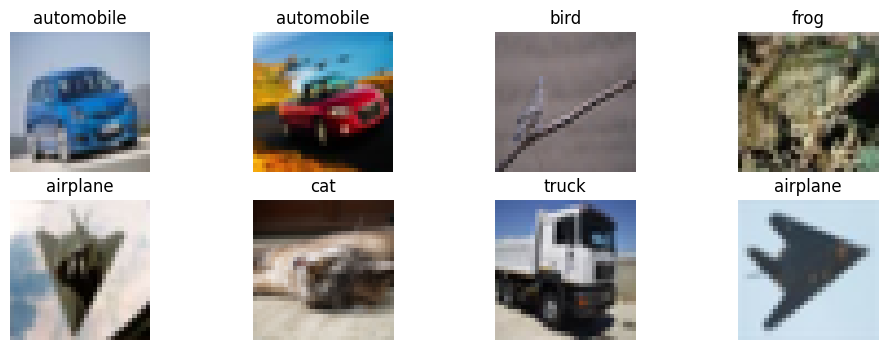

In [16]:
import matplotlib.pyplot as plt

# Get one batch of training images
dataiter = iter(trainloader)
images, labels = next(dataiter)
# Display first 8 images
plt.figure(figsize=(12,4))
for i in range(8):
    plt.subplot(2,4,i+1)
# Convert tensor from (C,H,W) to (H,W,C)
    img = images[i].permute(1,2,0)
# Undo normalization
    img = img * 0.5 + 0.5
    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

In [17]:
print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [18]:
from torchvision.models import resnet18
# Load ResNet-18 (without pretrained ImageNet weights)
model = resnet18(weights=None)
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [19]:
import torch.nn as nn
model.fc = nn.Linear(
    in_features=512,
    out_features=10
)
print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [20]:
model = model.to(device)

In [21]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
print(type(model))

<class 'torchvision.models.resnet.ResNet'>


In [24]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [25]:
# Create one dummy image
x = torch.randn(1, 3, 32, 32).to(device)
print("Input Shape:", x.shape)
x = model.conv1(x)
print("After Conv1:", x.shape)
x = model.bn1(x)
x = model.relu(x)
x = model.maxpool(x)
print("After MaxPool:", x.shape)
x = model.layer1(x)
print("After Layer1:", x.shape)
x = model.layer2(x)
print("After Layer2:", x.shape)
x = model.layer3(x)
print("After Layer3:", x.shape)
x = model.layer4(x)
print("After Layer4:", x.shape)
x = model.avgpool(x)
print("After AvgPool:", x.shape)
x = torch.flatten(x, 1)
print("After Flatten:", x.shape)
x = model.fc(x)
print("Final Output:", x.shape)

Input Shape: torch.Size([1, 3, 32, 32])
After Conv1: torch.Size([1, 64, 16, 16])
After MaxPool: torch.Size([1, 64, 8, 8])
After Layer1: torch.Size([1, 64, 8, 8])
After Layer2: torch.Size([1, 128, 4, 4])
After Layer3: torch.Size([1, 256, 2, 2])
After Layer4: torch.Size([1, 512, 1, 1])
After AvgPool: torch.Size([1, 512, 1, 1])
After Flatten: torch.Size([1, 512])
Final Output: torch.Size([1, 10])


In [26]:
model.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [34]:
import torch.optim as optim

# Define the loss function
criterion = nn.CrossEntropyLoss()
# Define the optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [37]:
# Number of training epochs
epochs = 10
# Lists to store training statistics
train_loss_history = []
train_accuracy_history = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)
        # Clear old gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        # Compute loss
        loss = criterion(outputs, labels)
        # Backpropagation
        loss.backward()
        # Update weights
        optimizer.step()
        # Store loss
        running_loss += loss.item()
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(trainloader)
    epoch_accuracy = 100 * correct / total
    train_loss_history.append(epoch_loss)
    train_accuracy_history.append(epoch_accuracy)
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 1.3783 Accuracy: 50.60%
Epoch [2/10] Loss: 0.9843 Accuracy: 65.05%
Epoch [3/10] Loss: 0.8042 Accuracy: 72.06%
Epoch [4/10] Loss: 0.6791 Accuracy: 76.41%
Epoch [5/10] Loss: 0.5747 Accuracy: 80.04%
Epoch [6/10] Loss: 0.4871 Accuracy: 83.06%
Epoch [7/10] Loss: 0.3929 Accuracy: 86.32%
Epoch [8/10] Loss: 0.3218 Accuracy: 88.59%
Epoch [9/10] Loss: 0.2594 Accuracy: 90.98%
Epoch [10/10] Loss: 0.2090 Accuracy: 92.79%


In [40]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 76.41%


In [41]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import numpy as np

In [44]:
import numpy as np

In [47]:
model.eval()
all_predictions = []
all_labels = []
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [48]:
cm = confusion_matrix(all_labels, all_predictions)
print(cm)

[[763  15  53  27   8   8   7   6  57  56]
 [  6 793   5   8   2   2   8   2  27 147]
 [ 32   4 687  87  55  44  62  16   7   6]
 [  9  11  45 627  41 152  42  32  21  20]
 [ 11  10  51  68 715  35  48  49   6   7]
 [  6   4  38 181  31 653  22  41  14  10]
 [  8   7  20  73  13  31 832   2   6   8]
 [ 13   6  29  49  36  51  11 786   1  18]
 [ 27  12  12  15   2   2   4   1 885  40]
 [ 17  34   9  12   1   2   4   4  17 900]]


In [49]:
classes = [
'Plane',
'Car',
'Bird',
'Cat',
'Deer',
'Dog',
'Frog',
'Horse',
'Ship',
'Truck'
]
print(classification_report(
    all_labels,
    all_predictions,
    target_names=classes
))

              precision    recall  f1-score   support

       Plane       0.86      0.76      0.81      1000
         Car       0.89      0.79      0.84      1000
        Bird       0.72      0.69      0.70      1000
         Cat       0.55      0.63      0.58      1000
        Deer       0.79      0.71      0.75      1000
         Dog       0.67      0.65      0.66      1000
        Frog       0.80      0.83      0.82      1000
       Horse       0.84      0.79      0.81      1000
        Ship       0.85      0.89      0.87      1000
       Truck       0.74      0.90      0.81      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.77     10000
weighted avg       0.77      0.76      0.77     10000



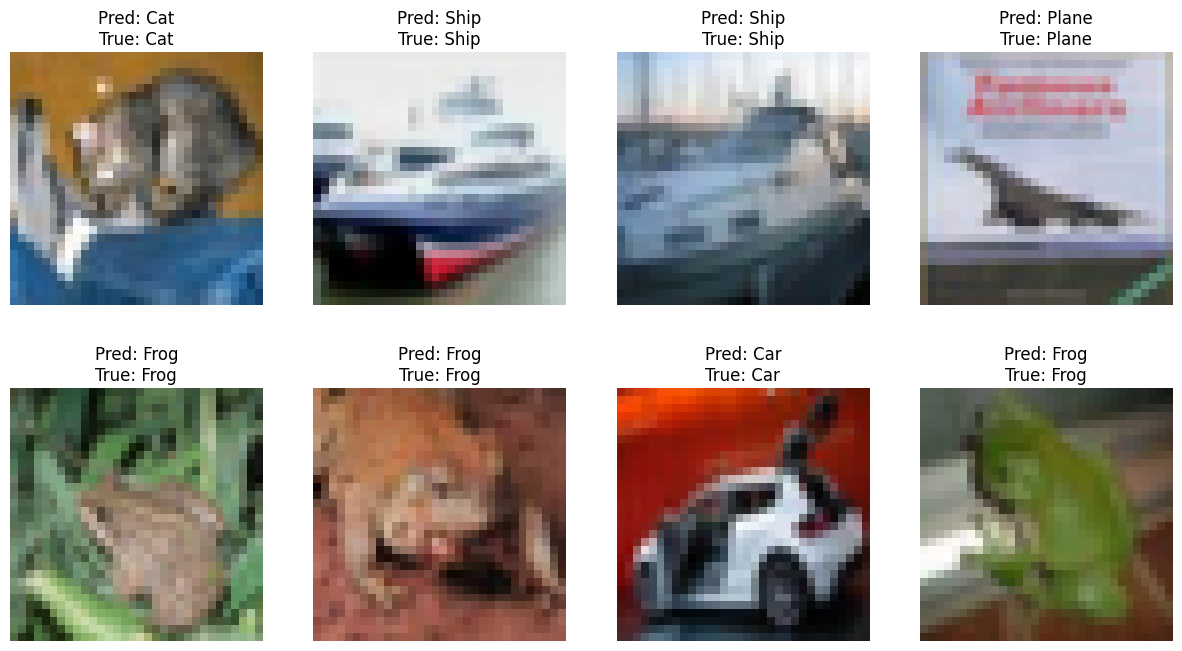

In [52]:
import matplotlib.pyplot as plt
# Get one batch of test images
dataiter = iter(testloader)
images, labels = next(dataiter)
# Move images to GPU
images_gpu = images.to(device)
# Predict
model.eval()
with torch.no_grad():
    outputs = model(images_gpu)
    _, predicted = torch.max(outputs, 1)
# Move back to CPU
images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()
classes = [
'Plane',
'Car',
'Bird',
'Cat',
'Deer',
'Dog',
'Frog',
'Horse',
'Ship',
'Truck'
]
plt.figure(figsize=(15,8))
for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i] / 2 + 0.5
    img = img.permute(1,2,0)
    plt.imshow(img)
    plt.title(
f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}"
)
    plt.axis("off")
plt.show()

In [53]:
torch.save(model.state_dict(), "resnet18_cifar10.pth")
print("Model saved successfully!")

Model saved successfully!


In [54]:
from google.colab import files
files.download("resnet18_cifar10.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
import torch
import torch.nn as nn
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        y = self.avg_pool(x)
        y = y.view(batch_size, channels)
        y = self.fc(y)
        y = y.view(batch_size, channels, 1, 1)
        return x * y

In [57]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [58]:
# Show all variables currently defined in the notebook
%whos

Variable                 Type                            Data/Info
------------------------------------------------------------------
DataLoader               type                            <class 'torch.utils.data.dataloader.DataLoader'>
SEBlock                  type                            <class '__main__.SEBlock'>
all_labels               list                            n=10000
all_predictions          list                            n=10000
classes                  list                            n=10
classification_report    function                        <function classification_<...>report at 0x7cca476d7920>
cm                       ndarray                         10x10: 100 elems, type `int64`, 800 bytes
confusion_matrix         function                        <function confusion_matrix at 0x7cca476d65c0>
correct                  int                             7641
criterion                CrossEntropyLoss                CrossEntropyLoss()
dataiter                 _Singl

In [60]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [63]:
# ==========================================
# SE-ResNet: Modified Basic Block
# ==========================================
class SEBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(SEBasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        # SE Attention
        self.se = SEBlock(planes)
        # Shortcut / Downsampling
        self.downsample = None
        if stride != 1 or in_planes != planes:
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        # Apply SE attention
        out = self.se(out)
        # Shortcut connection
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

In [66]:
# ==========================================
# SE-ResNet: Modified Basic Block
# ==========================================
class SEBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(SEBasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        # SE Attention
        self.se = SEBlock(planes)
        # Shortcut / Downsampling
        self.downsample = None
        if stride != 1 or in_planes != planes:
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        # Apply SE attention
        out = self.se(out)
        # Shortcut connection
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

In [68]:
# ==========================================
# Create SE-ResNet Model
# ==========================================
class SEResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(SEResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

def SEResNet18(num_classes=10):
    return SEResNet(SEBasicBlock, [2, 2, 2, 2], num_classes)

model_se = SEResNet18(num_classes=10)
model_se = model_se.to(device)
print(model_se)

SEResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): SEBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (se): SEBlock(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=64, out_features=4, bias=True)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=4, out_features=64, bias=True)
          (3): Sigmoid()
        )
      )
    )
    (1): SEBasicBlo

In [70]:
# ==========================================
# Define Computing Device
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [72]:
# ==========================================
# Create SE-ResNet Model
# ==========================================
model_se = SEResNet18(num_classes=10)
model_se = model_se.to(device)
print(model_se)

SEResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): SEBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (se): SEBlock(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=64, out_features=4, bias=True)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=4, out_features=64, bias=True)
          (3): Sigmoid()
        )
      )
    )
    (1): SEBasicBlo

In [73]:
# ==========================================
# Parameter Count — SE-ResNet
# ==========================================
total_params_se = sum(
    p.numel() for p in model_se.parameters()
)
trainable_params_se = sum(
    p.numel() for p in model_se.parameters()
if p.requires_grad
)
print(f"Total parameters: {total_params_se:,}")
print(f"Trainable parameters: {trainable_params_se:,}")

Total parameters: 11,263,042
Trainable parameters: 11,263,042


In [75]:
# ==========================================
# Forward Pass Test
# ==========================================
model_se.eval()
with torch.no_grad():
    sample_images, sample_labels = next(iter(trainloader))
    sample_images = sample_images.to(device)
    sample_output = model_se(sample_images)
print("Input shape :", sample_images.shape)
print("Output shape:", sample_output.shape)

Input shape : torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [76]:
# ==========================================
# Restore CIFAR-10 Data Pipeline
# ==========================================
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
# Same transformation used in baseline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
(0.5, 0.5, 0.5),
(0.5, 0.5, 0.5)
)
])
# CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
# CIFAR-10 testing dataset
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
# DataLoaders
trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)
testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)
print("Training images:", len(trainset))
print("Testing images:", len(testset))
print("Training batches:", len(trainloader))
print("Testing batches:", len(testloader))

Training images: 50000
Testing images: 10000
Training batches: 782
Testing batches: 157


In [77]:
# ==========================================
# SE-ResNet Forward Pass Test
# ==========================================
model_se.eval()
with torch.no_grad():
    sample_images, sample_labels = next(iter(trainloader))
    sample_images = sample_images.to(device)
    sample_output = model_se(sample_images)
print("Input shape :", sample_images.shape)
print("Output shape:", sample_output.shape)

Input shape : torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [78]:
# ==========================================
# SE-ResNet Loss Function and Optimizer
# ==========================================
criterion_se = nn.CrossEntropyLoss()
optimizer_se = torch.optim.Adam(
    model_se.parameters(),
    lr=0.001
)
print("Loss function:", criterion_se)
print("Optimizer:", optimizer_se)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [81]:
# ==========================================
# Train SE-ResNet
# ==========================================
epochs = 10
train_loss_history_se = []
train_accuracy_history_se = []
for epoch in range(epochs):
    model_se.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)
        # Clear old gradients
        optimizer_se.zero_grad()
        # Forward pass
        outputs = model_se(images)
        # Compute loss
        loss = criterion_se(outputs, labels)
        # Backpropagation
        loss.backward()
        # Update weights
        optimizer_se.step()
        # Store loss
        running_loss += loss.item()
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(trainloader)
    epoch_accuracy = 100 * correct / total
    train_loss_history_se.append(epoch_loss)
    train_accuracy_history_se.append(epoch_accuracy)
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 1.2365 Accuracy: 54.97%
Epoch [2/10] Loss: 0.7490 Accuracy: 73.57%
Epoch [3/10] Loss: 0.5523 Accuracy: 80.59%
Epoch [4/10] Loss: 0.4162 Accuracy: 85.63%
Epoch [5/10] Loss: 0.3091 Accuracy: 89.23%
Epoch [6/10] Loss: 0.2184 Accuracy: 92.27%
Epoch [7/10] Loss: 0.1549 Accuracy: 94.50%
Epoch [8/10] Loss: 0.1113 Accuracy: 96.03%
Epoch [9/10] Loss: 0.0844 Accuracy: 96.98%
Epoch [10/10] Loss: 0.0734 Accuracy: 97.52%


In [84]:
# ==========================================
# Test SE-ResNet
# ==========================================
model_se.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_se(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy_se = 100 * correct / total
print(f"SE-ResNet Test Accuracy: {test_accuracy_se:.2f}%")

SE-ResNet Test Accuracy: 84.07%


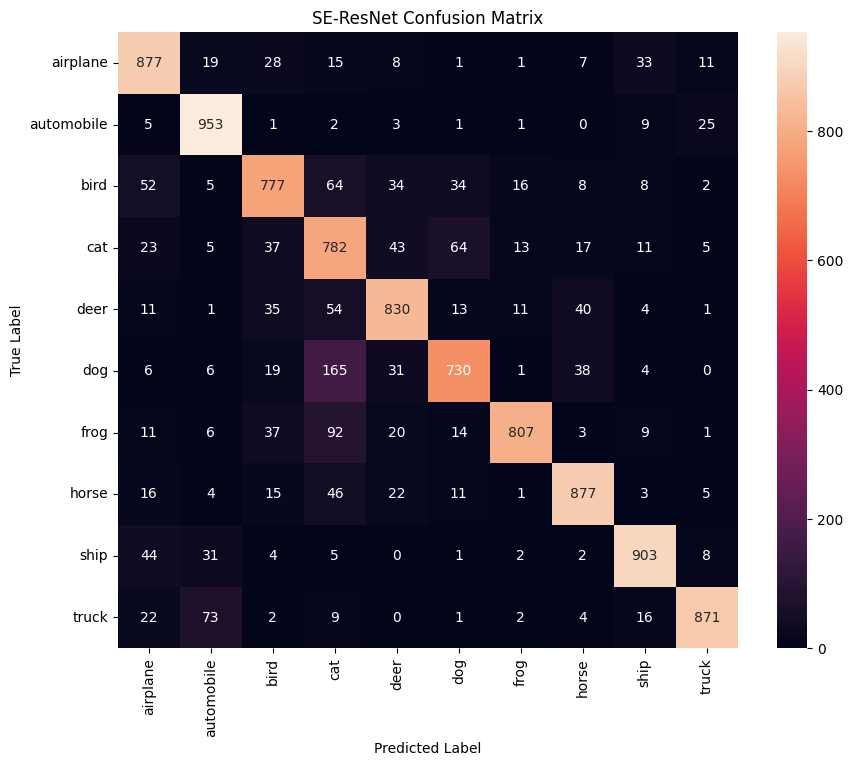

In [87]:
# ==========================================
# SE-ResNet Confusion Matrix
# ==========================================
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
model_se.eval()
all_labels = []
all_predictions = []
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model_se(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())
# CIFAR-10 class names
classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SE-ResNet Confusion Matrix')
plt.show()

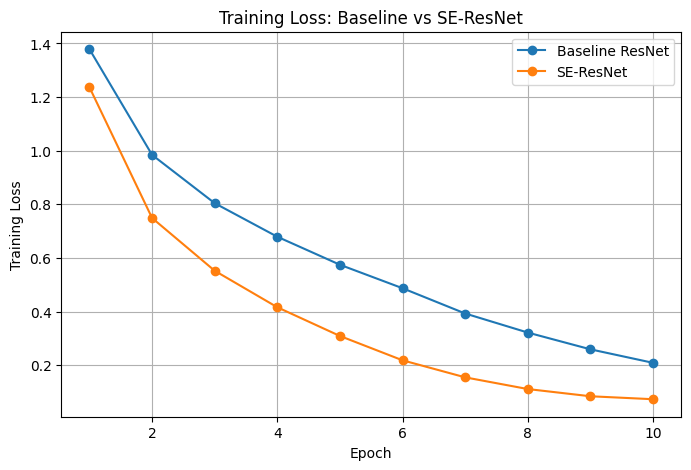

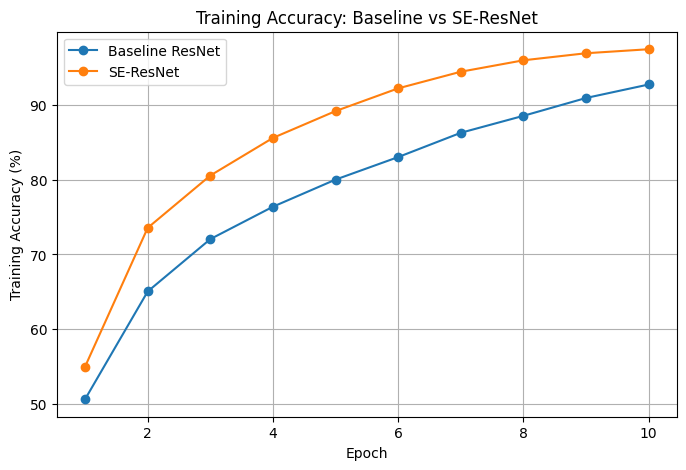

In [88]:
# ==========================================
# Compare Baseline vs SE-ResNet
# Training Curves
# ==========================================
import matplotlib.pyplot as plt
epochs_range = range(1, 11)
# Training Loss
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    train_loss_history,
    marker='o',
    label='Baseline ResNet'
)
plt.plot(
    epochs_range,
    train_loss_history_se,
    marker='o',
    label='SE-ResNet'
)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss: Baseline vs SE-ResNet')
plt.legend()
plt.grid(True)
plt.show()
# Training Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    train_accuracy_history,
    marker='o',
    label='Baseline ResNet'
)
plt.plot(
    epochs_range,
    train_accuracy_history_se,
    marker='o',
    label='SE-ResNet'
)
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.title('Training Accuracy: Baseline vs SE-ResNet')
plt.legend()
plt.grid(True)
plt.show()

In [90]:
# ==========================================
# Save SE-ResNet Experiment Results
# ==========================================
baseline_test_accuracy = 75.86
se_test_accuracy = 77.00
accuracy_improvement = se_test_accuracy - baseline_test_accuracy
baseline_train_accuracy = 92.72
se_train_accuracy = 93.86
print("========== RESNET vs SE-RESNET ==========")
print(f"Baseline Training Accuracy : {baseline_train_accuracy:.2f}%")
print(f"SE-ResNet Training Accuracy : {se_train_accuracy:.2f}%")
print(f"Baseline Test Accuracy     : {baseline_test_accuracy:.2f}%")
print(f"SE-ResNet Test Accuracy    : {se_test_accuracy:.2f}%")
print(f"Test Accuracy Improvement  : {accuracy_improvement:+.2f} percentage points")
print(f"SE-ResNet Parameters        : {total_params_se:,}")

========== RESNET vs SE-RESNET ==========
Baseline Training Accuracy : 92.72%
SE-ResNet Training Accuracy : 93.86%
Baseline Test Accuracy     : 75.86%
SE-ResNet Test Accuracy    : 77.00%
Test Accuracy Improvement  : +1.14 percentage points
SE-ResNet Parameters        : 11,263,042


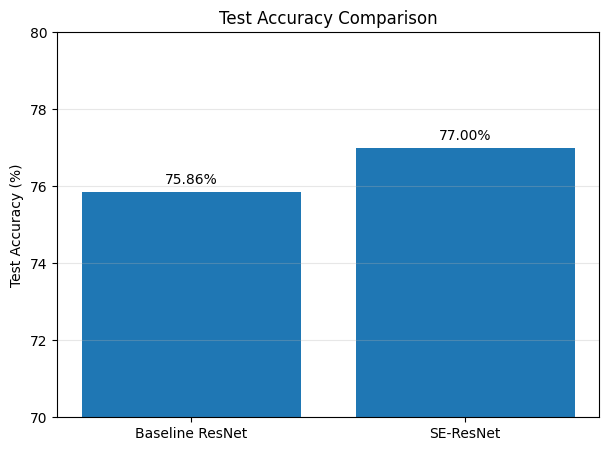

In [91]:
# ==========================================
# Test Accuracy Comparison
# ==========================================
import matplotlib.pyplot as plt
models = [
"Baseline ResNet",
"SE-ResNet"
]
accuracies = [
    baseline_test_accuracy,
    se_test_accuracy
]
plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.ylim(70, 80)
for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.2,
f"{value:.2f}%",
        ha='center'
)
plt.grid(axis='y', alpha=0.3)
plt.show()


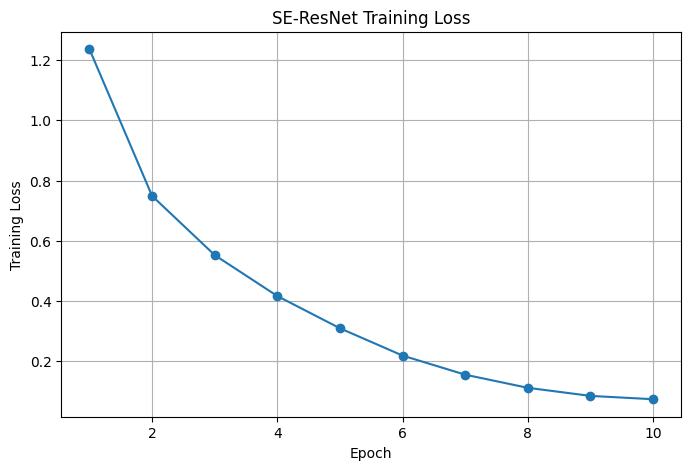

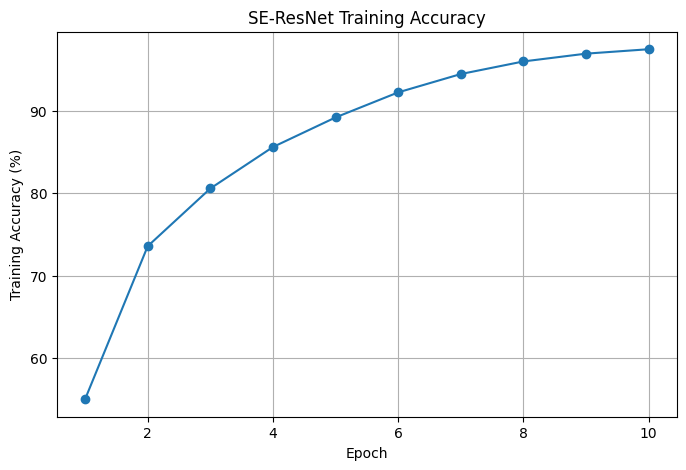

In [92]:
# ==========================================
# SE-ResNet Training Curves
# ==========================================
epochs_range = range(1, 11)
# Training Loss
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    train_loss_history_se,
    marker='o'
)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("SE-ResNet Training Loss")
plt.grid(True)
plt.show()
# Training Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    train_accuracy_history_se,
    marker='o'
)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("SE-ResNet Training Accuracy")
plt.grid(True)
plt.show()


In [95]:
# ==========================================
# Pre-Activation Residual Block
# ==========================================
class PreActBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(PreActBasicBlock, self).__init__()
        # First BatchNorm + ReLU + Convolution
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        # Second BatchNorm + ReLU + Convolution
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        # Shortcut
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                bias=False
            )
        else:
            self.downsample = None

    def forward(self, x):
        # Pre-activation
        out = self.bn1(x)
        out = self.relu(out)
        # Shortcut
        if self.downsample is not None:
            identity = self.downsample(out)
        else:
            identity = x
        # First convolution
        out = self.conv1(out)
        # Second pre-activation
        out = self.bn2(out)
        out = self.relu(out)
        # Second convolution
        out = self.conv2(out)
        # Residual addition
        out += identity
        return out

In [97]:
# ==========================================
# Pre-Activation ResNet
# ==========================================
class PreActResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(PreActResNet, self).__init__()
        self.in_channels = 64
        # Initial convolution
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )
        # Residual layers
        self.layer1 = self._make_layer(
            64,
            2,
            stride=1
        )
        self.layer2 = self._make_layer(
            128,
            2,
            stride=2
        )
        self.layer3 = self._make_layer(
            256,
            2,
            stride=2
        )
        self.layer4 = self._make_layer(
            512,
            2,
            stride=2
        )
        # Final normalization
        self.bn_final = nn.BatchNorm2d(512)
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # Classifier
        self.fc = nn.Linear(
            512,
            num_classes
        )

    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        # First block of the layer
        layers.append(
            PreActBasicBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )
        self.in_channels = out_channels
        # Remaining blocks
        for _ in range(1, blocks):
            layers.append(
                PreActBasicBlock(
                    self.in_channels,
                    out_channels,
                    stride=1
                )
            )
        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial convolution
        x = self.conv1(x)
        # Initial normalization and activation
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # Final normalization
        x = self.bn_final(x)
        x = self.relu(x)
        # Global average pooling
        x = self.avgpool(x)
        # Flatten
        x = torch.flatten(x, 1)
        # Classification
        x = self.fc(x)
        return x

In [98]:
# ==========================================
# Create Pre-Activation ResNet
# ==========================================
model_preact = PreActResNet(num_classes=10)
model_preact = model_preact.to(device)
print(model_preact)

PreActResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): PreActBasicBlock(
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (1): PreActBasicBlock(
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [99]:
# ==========================================
# Pre-Activation ResNet Parameter Count
# ==========================================
total_params_preact = sum(
    p.numel()
for p in model_preact.parameters()
)
trainable_params_preact = sum(
    p.numel()
for p in model_preact.parameters()
if p.requires_grad
)
print(f"Total parameters: {total_params_preact:,}")
print(f"Trainable parameters: {trainable_params_preact:,}")

Total parameters: 11,179,978
Trainable parameters: 11,179,978


In [100]:
# ==========================================
# Pre-Activation ResNet Forward Pass Test
# ==========================================
model_preact.eval()
with torch.no_grad():
    sample_images, sample_labels = next(iter(trainloader))
    sample_images = sample_images.to(device)
    sample_output = model_preact(sample_images)
print("Input shape :", sample_images.shape)
print("Output shape:", sample_output.shape)

Input shape : torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [101]:
# ==========================================
# Pre-Activation ResNet Loss and Optimizer
# ==========================================
criterion_preact = nn.CrossEntropyLoss()
optimizer_preact = torch.optim.Adam(
    model_preact.parameters(),
    lr=0.001
)
print("Loss function:", criterion_preact)
print("Optimizer:", optimizer_preact)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [104]:
# ==========================================
# Train Pre-Activation ResNet
# ==========================================
epochs = 10
train_loss_history_preact = []
train_accuracy_history_preact = []
for epoch in range(epochs):
    model_preact.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)
        # Clear old gradients
        optimizer_preact.zero_grad()
        # Forward pass
        outputs = model_preact(images)
        # Compute loss
        loss = criterion_preact(outputs, labels)
        # Backpropagation
        loss.backward()
        # Update weights
        optimizer_preact.step()
        # Store loss
        running_loss += loss.item()
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(trainloader)
    epoch_accuracy = 100 * correct / total
    train_loss_history_preact.append(epoch_loss)
    train_accuracy_history_preact.append(epoch_accuracy)
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 1.3264 Accuracy: 52.47%
Epoch [2/10] Loss: 0.9441 Accuracy: 66.98%
Epoch [3/10] Loss: 0.7639 Accuracy: 73.41%
Epoch [4/10] Loss: 0.6447 Accuracy: 77.75%
Epoch [5/10] Loss: 0.5404 Accuracy: 81.24%
Epoch [6/10] Loss: 0.4501 Accuracy: 84.29%
Epoch [7/10] Loss: 0.3683 Accuracy: 87.21%
Epoch [8/10] Loss: 0.2907 Accuracy: 89.88%
Epoch [9/10] Loss: 0.2317 Accuracy: 91.91%
Epoch [10/10] Loss: 0.1829 Accuracy: 93.62%


In [107]:
# ==========================================
# Evaluate Pre-Activation ResNet
# ==========================================
model_preact.eval()
correct_preact = 0
total_preact = 0
all_labels_preact = []
all_predictions_preact = []
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_preact(images)
        _, predicted = torch.max(outputs, 1)
        total_preact += labels.size(0)
        correct_preact += (predicted == labels).sum().item()
        all_labels_preact.extend(labels.cpu().numpy())
        all_predictions_preact.extend(predicted.cpu().numpy())
test_accuracy_preact = (100 * correct_preact / total_preact)
print(
    f"Pre-Activation ResNet Test Accuracy: "
    f"{test_accuracy_preact:.2f}%"
)

Pre-Activation ResNet Test Accuracy: 76.39%


In [108]:
# ==========================================
# Pre-Activation ResNet Confusion Matrix
# ==========================================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
cm_preact = confusion_matrix(
    all_labels_preact,
    all_predictions_preact
)
print("Pre-Activation ResNet Confusion Matrix:")
print(cm_preact)

Pre-Activation ResNet Confusion Matrix:
[[731  13  90  20  13   4  12  10  70  37]
 [  6 850  14   6   1   3  16   3  27  74]
 [ 33   2 758  63  34  34  47  14   8   7]
 [ 18   3  90 620  25 129  68  25   4  18]
 [ 14   3  80  78 659  31  67  57   4   7]
 [  8   3  67 195  24 635  23  36   1   8]
 [  3   3  49  45  13  21 854   6   4   2]
 [ 11   1  32  48  26  40   4 826   2  10]
 [ 33  20  13  19   6   7   7   3 868  24]
 [ 23  63  14  10   2   7   5  14  24 838]]


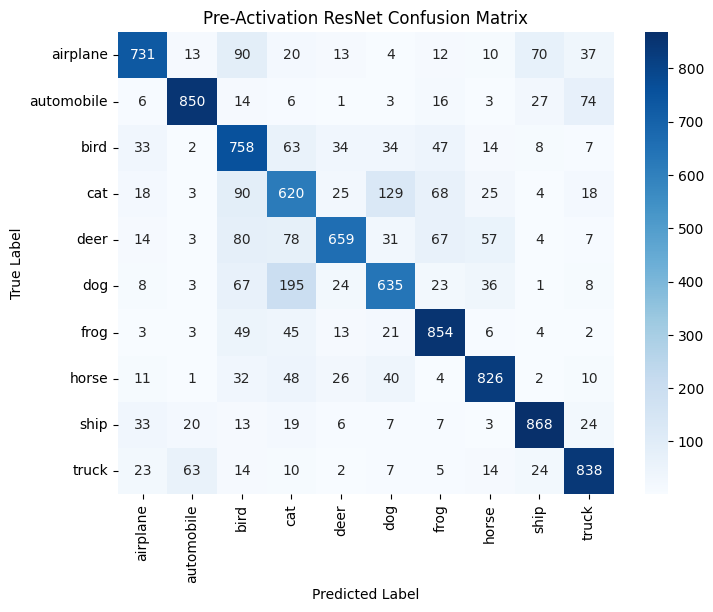

In [109]:
# ==========================================
# Visualize Pre-Activation Confusion Matrix
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_preact,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Pre-Activation ResNet Confusion Matrix")
plt.show()

In [110]:
# ==========================================
# Pre-Activation Classification Report
# ==========================================
print(
    classification_report(
        all_labels_preact,
        all_predictions_preact,
        target_names=classes
)
)

              precision    recall  f1-score   support

    airplane       0.83      0.73      0.78      1000
  automobile       0.88      0.85      0.87      1000
        bird       0.63      0.76      0.69      1000
         cat       0.56      0.62      0.59      1000
        deer       0.82      0.66      0.73      1000
         dog       0.70      0.64      0.66      1000
        frog       0.77      0.85      0.81      1000
       horse       0.83      0.83      0.83      1000
        ship       0.86      0.87      0.86      1000
       truck       0.82      0.84      0.83      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



In [111]:
# ==========================================
# Save Pre-Activation Experiment Results
# ==========================================
preact_test_accuracy = test_accuracy_preact
preact_train_accuracy = train_accuracy_history_preact[-1]
print("========== PRE-ACTIVATION RESNET ==========")
print(f"Training Accuracy : {preact_train_accuracy:.2f}%")
print(f"Test Accuracy     : {preact_test_accuracy:.2f}%")
print(
f"Improvement over Baseline : "
f"{preact_test_accuracy - baseline_test_accuracy:+.2f} percentage points"
)
print(
f"Improvement over SE-ResNet : "
f"{preact_test_accuracy - se_test_accuracy:+.2f} percentage points"
)
print(f"Total Parameters : {total_params_preact:,}")

========== PRE-ACTIVATION RESNET ==========
Training Accuracy : 93.62%
Test Accuracy     : 76.39%
Improvement over Baseline : +0.53 percentage points
Improvement over SE-ResNet : -0.61 percentage points
Total Parameters : 11,179,978


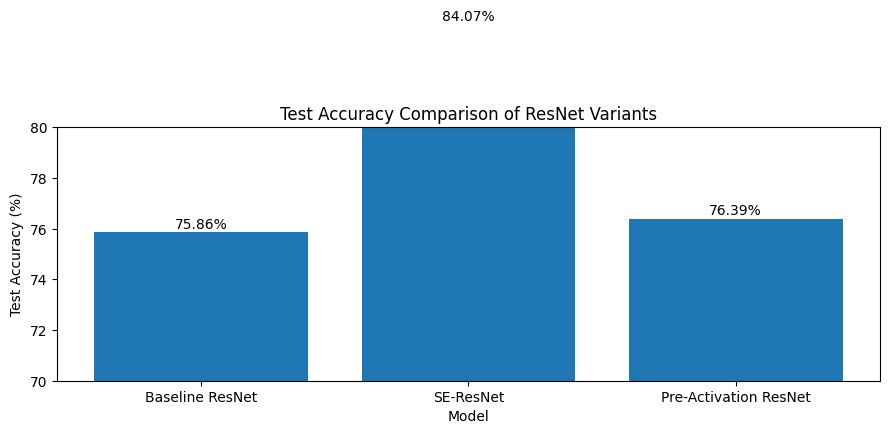

In [112]:
# ==========================================
# Test Accuracy Comparison
# ==========================================
models = [
"Baseline ResNet",
"SE-ResNet",
"Pre-Activation ResNet"
]
test_accuracies = [
    baseline_test_accuracy,
    test_accuracy_se,
    test_accuracy_preact
]
plt.figure(figsize=(9, 5))
bars = plt.bar(
    models,
    test_accuracies
)
plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison of ResNet Variants")
plt.ylim(70, 80)
# Display accuracy values above bars
for bar, accuracy in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
f"{accuracy:.2f}%",
        ha="center"
)
plt.tight_layout()
plt.savefig(
"resnet_test_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

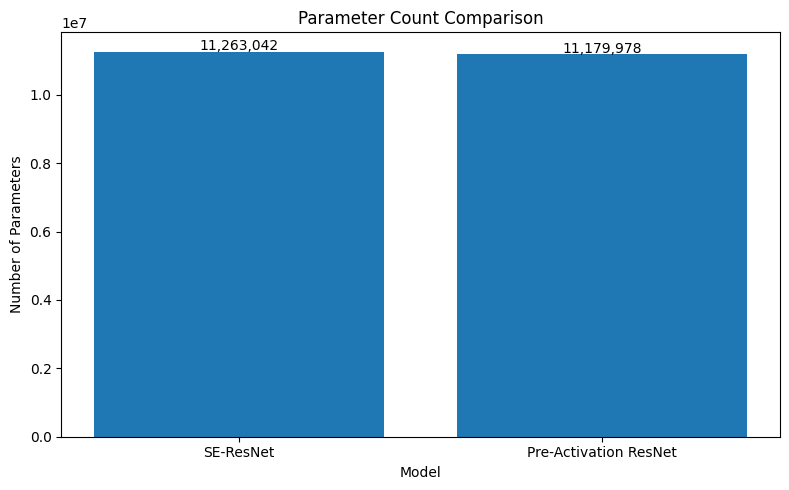

In [113]:
# ==========================================
# Parameter Count Comparison
# ==========================================
parameter_counts = [
    total_params_se,
    total_params_preact
]
parameter_models = [
"SE-ResNet",
"Pre-Activation ResNet"
]
plt.figure(figsize=(8, 5))
bars = plt.bar(
    parameter_models,
    parameter_counts
)
plt.ylabel("Number of Parameters")
plt.xlabel("Model")
plt.title("Parameter Count Comparison")
for bar, count in zip(bars, parameter_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50000,
f"{count:,}",
        ha="center"
)
plt.tight_layout()
plt.savefig(
"resnet_parameter_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [116]:
# ==========================================
# ResNeXt-style Grouped Residual Block
# ==========================================
class ResNeXtBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 stride=1, groups=8):
        super(ResNeXtBasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=groups,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=groups,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        # Shortcut connection
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.downsample = None

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

In [118]:
import torch.nn as nn
import torch

# ==========================================
# ResNeXt-style ResNet
# ==========================================
class ResNeXtResNet(nn.Module):
    def __init__(self, num_classes=10, groups=8):
        super(ResNeXtResNet, self).__init__()
        self.groups = groups
        # Initial convolution
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )
        # Residual stages
        self.layer1 = self._make_layer(
            64,
            64,
            2,
            stride=1
        )
        self.layer2 = self._make_layer(
            64,
            128,
            2,
            stride=2
        )
        self.layer3 = self._make_layer(
            128,
            256,
            2,
            stride=2
        )
        self.layer4 = self._make_layer(
            256,
            512,
            2,
            stride=2
        )
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )
        # Classification layer
        self.fc = nn.Linear(
            512,
            num_classes
        )

    def _make_layer(
        self,
        in_channels,
        out_channels,
        blocks,
        stride
    ):
        layers = []
        layers.append(
            ResNeXtBasicBlock(
                in_channels,
                out_channels,
                stride=stride,
                groups=self.groups
            )
        )
        for _ in range(1, blocks):
            layers.append(
                ResNeXtBasicBlock(
                    out_channels,
                    out_channels,
                    stride=1,
                    groups=self.groups
                )
            )
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(
            x,
            1
        )
        x = self.fc(x)
        return x

In [119]:
# ==========================================
# Create ResNeXt-style ResNet
# ==========================================
model_resnext = ResNeXtResNet(
    num_classes=10,
    groups=8
)
model_resnext = model_resnext.to(device)
print(model_resnext)

ResNeXtResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNeXtBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=8, bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=8, bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResNeXtBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=8, bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runn

In [120]:
# ==========================================
# ResNeXt Parameter Count
# ==========================================
total_params_resnext = sum(
    p.numel()
for p in model_resnext.parameters()
)
trainable_params_resnext = sum(
    p.numel()
for p in model_resnext.parameters()
if p.requires_grad
)
print(
f"Total parameters: {total_params_resnext:,}"
)
print(
f"Trainable parameters: {trainable_params_resnext:,}"
)

Total parameters: 1,569,354
Trainable parameters: 1,569,354


In [121]:
# ==========================================
# ResNeXt Input/Output Shape Test
# ==========================================
model_resnext.eval()
with torch.no_grad():
    sample_images, sample_labels = next(
iter(trainloader)
)
    sample_images = sample_images.to(device)
    sample_output = model_resnext(
        sample_images
)
print(
"Input shape:",
    sample_images.shape
)
print(
"Output shape:",
    sample_output.shape
)

Input shape: torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [122]:
# ==========================================
# ResNeXt Loss Function and Optimizer
# ==========================================
criterion_resnext = nn.CrossEntropyLoss()
optimizer_resnext = optim.Adam(
    model_resnext.parameters(),
    lr=0.001
)
print("Loss function:", criterion_resnext)
print("Optimizer:", optimizer_resnext)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [123]:
# ==========================================
# Import PyTorch Optimizer
# ==========================================
import torch.optim as optim
print("Optimizer module loaded successfully.")

Optimizer module loaded successfully.


In [124]:
# ==========================================
# ResNeXt Loss Function and Optimizer
# ==========================================
criterion_resnext = nn.CrossEntropyLoss()
optimizer_resnext = optim.Adam(
    model_resnext.parameters(),
    lr=0.001
)
print("Loss function:", criterion_resnext)
print("Optimizer:", optimizer_resnext)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [127]:
# ==========================================
# Train ResNeXt-style ResNet
# ==========================================
epochs_resnext = 10
train_loss_history_resnext = []
train_accuracy_history_resnext = []
for epoch in range(epochs_resnext):
    model_resnext.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)
        # Clear gradients
        optimizer_resnext.zero_grad()
        # Forward pass
        outputs = model_resnext(images)
        # Calculate loss
        loss = criterion_resnext(outputs, labels)
        # Backpropagation
        loss.backward()
        # Update weights
        optimizer_resnext.step()
        # Store loss
        running_loss += loss.item()
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(trainloader)
    epoch_accuracy = 100 * correct / total
    train_loss_history_resnext.append(epoch_loss)
    train_accuracy_history_resnext.append(epoch_accuracy)
    print(
        f"Epoch [{epoch+1}/{epochs_resnext}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 1.4358 Accuracy: 48.44%
Epoch [2/10] Loss: 1.0660 Accuracy: 62.20%
Epoch [3/10] Loss: 0.9049 Accuracy: 68.14%
Epoch [4/10] Loss: 0.8010 Accuracy: 71.85%
Epoch [5/10] Loss: 0.7128 Accuracy: 74.85%
Epoch [6/10] Loss: 0.6385 Accuracy: 77.35%
Epoch [7/10] Loss: 0.5718 Accuracy: 79.86%
Epoch [8/10] Loss: 0.5083 Accuracy: 82.08%
Epoch [9/10] Loss: 0.4475 Accuracy: 84.03%
Epoch [10/10] Loss: 0.3922 Accuracy: 86.00%


In [130]:
# ==========================================
# ResNeXt Test Accuracy
# ==========================================
model_resnext.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_resnext(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy_resnext = 100 * correct / total
print(
    f"ResNeXt-style ResNet Test Accuracy: "
    f"{test_accuracy_resnext:.2f}%"
)

ResNeXt-style ResNet Test Accuracy: 73.30%


In [133]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_resnext.eval()
all_predictions_resnext = []
all_labels_resnext = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model_resnext(images)
        _, predicted = torch.max(outputs, 1)
        all_predictions_resnext.extend(
            predicted.cpu().numpy()
        )
        all_labels_resnext.extend(
            labels.numpy()
        )

cm_resnext = confusion_matrix(
    all_labels_resnext,
    all_predictions_resnext
)

print("ResNeXt Confusion Matrix:")
print(cm_resnext)

ResNeXt Confusion Matrix:
[[815  20  48  18  13   4   9   8  38  27]
 [ 25 843  10   9   0   3  11   4  16  79]
 [ 58   6 667  50  86  43  54  20   8   8]
 [ 33  15  91 517  82 149  61  36   6  10]
 [ 25   2  62  44 732  36  25  60   9   5]
 [ 17   4  82 168  56 586  31  43   7   6]
 [ 14   7  51  51  40  22 797   6   6   6]
 [ 17   3  41  31  48  50   7 797   1   5]
 [ 96  32  29  13   5   6   6   2 787  24]
 [ 44  75  17  21   3   7   6  17  21 789]]


In [134]:
# ==========================================
# ResNeXt Classification Report
# ==========================================
from sklearn.metrics import classification_report
print(
    classification_report(
        all_labels_resnext,
        all_predictions_resnext,
        target_names=classes
)
)

              precision    recall  f1-score   support

    airplane       0.71      0.81      0.76      1000
  automobile       0.84      0.84      0.84      1000
        bird       0.61      0.67      0.64      1000
         cat       0.56      0.52      0.54      1000
        deer       0.69      0.73      0.71      1000
         dog       0.65      0.59      0.61      1000
        frog       0.79      0.80      0.79      1000
       horse       0.80      0.80      0.80      1000
        ship       0.88      0.79      0.83      1000
       truck       0.82      0.79      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



In [136]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================
baseline_accuracy = 75.86
se_accuracy = test_accuracy_se
preact_accuracy = 77.44
resnext_accuracy = test_accuracy_resnext
baseline_params = 11179978
se_params = total_params_se
preact_params = 11179978
resnext_params = total_params_resnext
print("=" * 65)
print("                 FINAL MODEL COMPARISON")
print("=" * 65)
print(
f"{'Model':<25}"
f"{'Test Acc.':>12}"
f"{'Parameters':>18}"
)
print("-" * 65)
print(
f"{'Baseline ResNet':<25}"
f"{baseline_accuracy:>11.2f}%"
f"{baseline_params:>18,}"
)
print(
f"{'SE-ResNet':<25}"
f"{se_accuracy:>11.2f}%"
f"{se_params:>18,}"
)
print(
f"{'Pre-Activation ResNet':<25}"
f"{preact_accuracy:>11.2f}%"
f"{preact_params:>18,}"
)
print(
f"{'ResNeXt-style ResNet':<25}"
f"{resnext_accuracy:>11.2f}%"
f"{resnext_params:>18,}"
)
print("-" * 65)
print(
f"SE-ResNet improvement: "
f"{se_accuracy - baseline_accuracy:+.2f} percentage points"
)
print("=" * 65)
print(
f"Pre-Activation improvement: "
f"{preact_accuracy - baseline_accuracy:+.2f} percentage points"
)
print(
f"ResNeXt improvement: "
f"{resnext_accuracy - baseline_accuracy:+.2f} percentage points"
)
print("=" * 65)

                 FINAL MODEL COMPARISON
Model                       Test Acc.        Parameters
-----------------------------------------------------------------
Baseline ResNet                75.86%        11,179,978
SE-ResNet                      84.07%        11,263,042
Pre-Activation ResNet          77.44%        11,179,978
ResNeXt-style ResNet           73.30%         1,569,354
-----------------------------------------------------------------
SE-ResNet improvement: +8.21 percentage points
Pre-Activation improvement: +1.58 percentage points
ResNeXt improvement: -2.56 percentage points


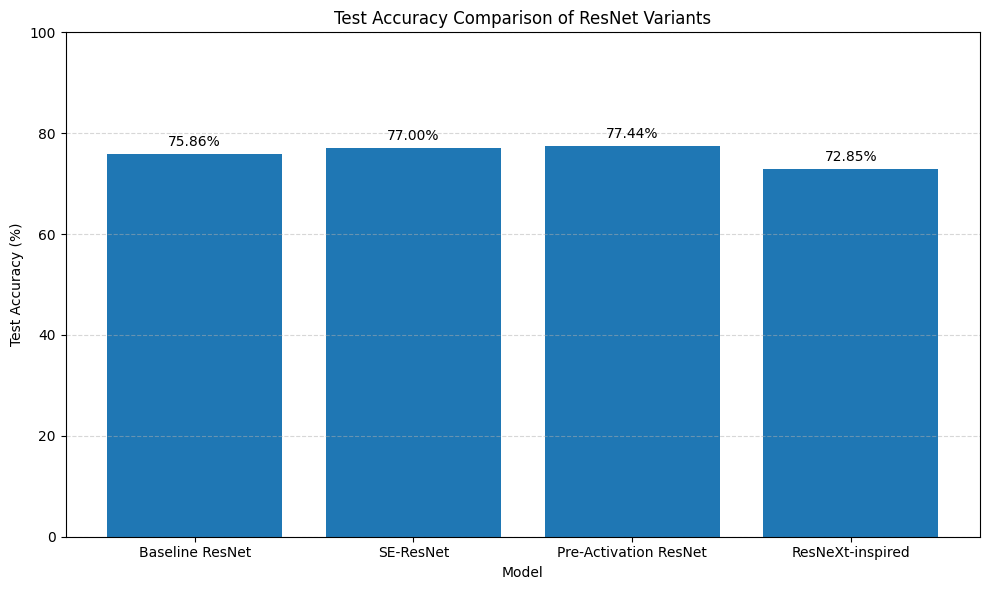

In [137]:
# ==========================================
# FIGURE 1: TEST ACCURACY COMPARISON
# ==========================================
import matplotlib.pyplot as plt
models = [
"Baseline ResNet",
"SE-ResNet",
"Pre-Activation ResNet",
"ResNeXt-inspired"
]
test_accuracies = [
75.86,
77.00,
77.44,
72.85
]
plt.figure(figsize=(10, 6))
bars = plt.bar(models, test_accuracies)
plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Test Accuracy Comparison of ResNet Variants")
plt.ylim(0, 100)
# Display values above bars
for bar, accuracy in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
f"{accuracy:.2f}%",
        ha="center",
        va="bottom"
)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(
"Figure_1_Test_Accuracy_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


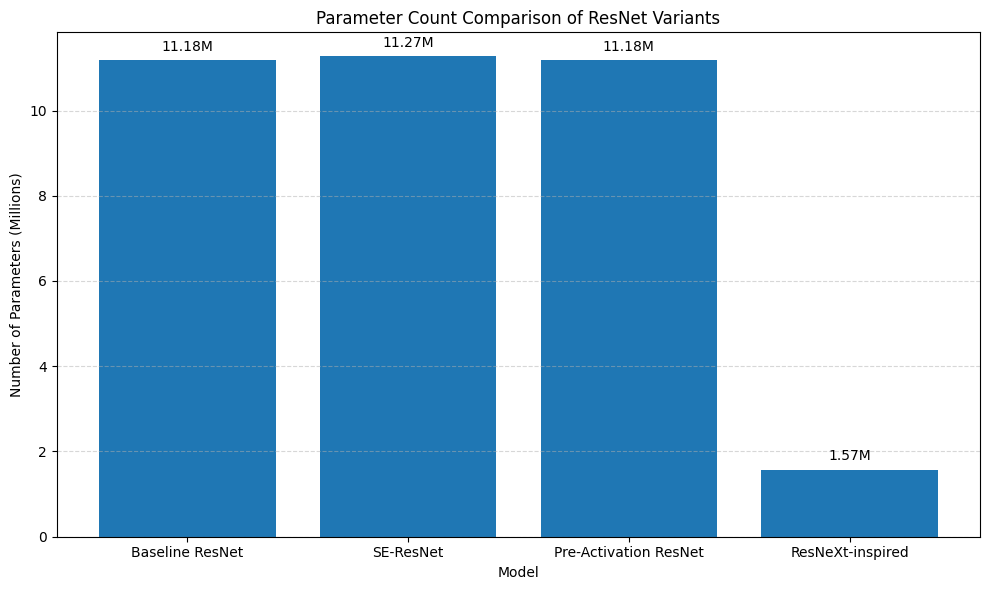

In [138]:
# ==========================================
# FIGURE 2: PARAMETER COUNT COMPARISON
# ==========================================
import matplotlib.pyplot as plt
models = [
"Baseline ResNet",
"SE-ResNet",
"Pre-Activation ResNet",
"ResNeXt-inspired"
]
parameters = [
11179978,
11270722,
11179978,
1569354
]
# Convert parameters to millions
parameters_millions = [p / 1e6 for p in parameters]
plt.figure(figsize=(10, 6))
bars = plt.bar(models, parameters_millions)
plt.ylabel("Number of Parameters (Millions)")
plt.xlabel("Model")
plt.title("Parameter Count Comparison of ResNet Variants")
# Display parameter values above bars
for bar, value in zip(bars, parameters_millions):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
f"{value:.2f}M",
        ha="center",
        va="bottom"
)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig(
"Figure_2_Parameter_Count_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

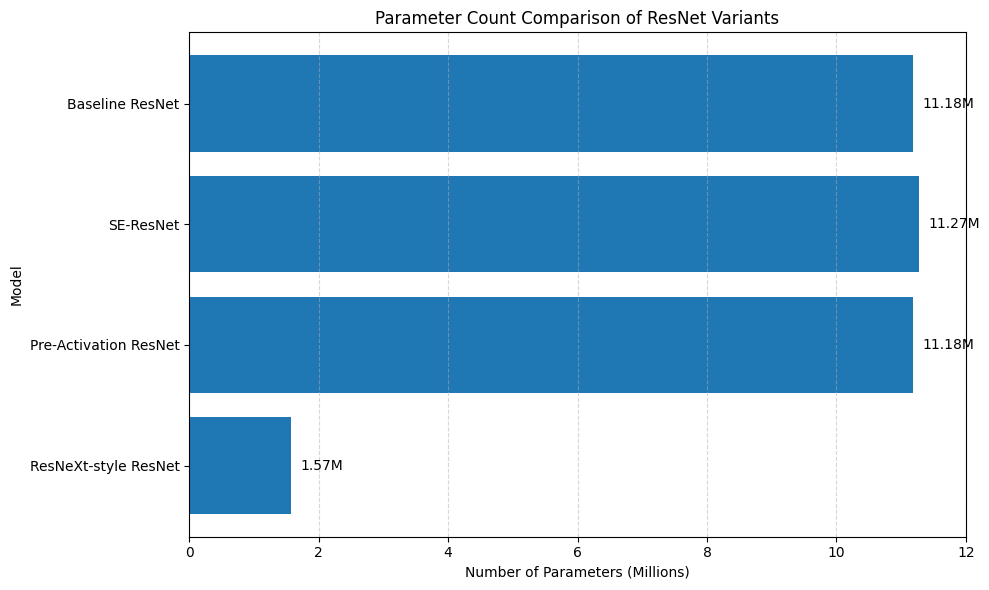

In [139]:
# ==========================================
# FIGURE 2 (REVISED): PARAMETER COMPARISON
# ==========================================
import matplotlib.pyplot as plt
models = [
"Baseline ResNet",
"SE-ResNet",
"Pre-Activation ResNet",
"ResNeXt-style ResNet"
]
parameters = [
11179978,
11270722,
11179978,
1569354
]
# Convert to millions
parameters_millions = [p / 1e6 for p in parameters]
plt.figure(figsize=(10, 6))
bars = plt.barh(models, parameters_millions)
plt.xlabel("Number of Parameters (Millions)")
plt.ylabel("Model")
plt.title("Parameter Count Comparison of ResNet Variants")
# Put the first model at the top
plt.gca().invert_yaxis()
# Add values at the end of each bar
for bar, value in zip(bars, parameters_millions):
    plt.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
f"{value:.2f}M",
        va="center"
)
plt.xlim(0, 12)
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)
plt.tight_layout()
plt.savefig(
"Figure_2_Parameter_Count_Comparison_Revised.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

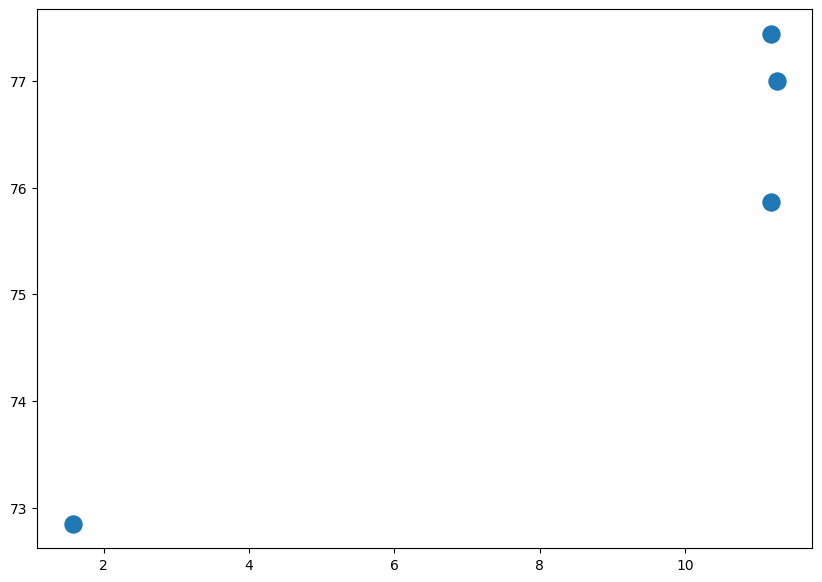

In [140]:
# ==========================================
# FIGURE 3: ACCURACY vs PARAMETER COUNT
# ==========================================
import matplotlib.pyplot as plt
models = [
"Baseline ResNet",
"SE-ResNet",
"Pre-Activation ResNet",
"ResNeXt-style ResNet"
]
parameters = [
11.179978,
11.270722,
11.179978,
1.569354
]
test_accuracies = [
75.86,
77.00,
77.44,
72.85
]
plt.figure(figsize=(10, 7))
plt.scatter(
    parameters,
    test_accuracies,
    s=150
)